In [1]:
## Unifys the activity scale for all proteins

# Read in data frame 
# Scale for diffren data sets
## Imin Reductase Sigmoid scaling -> read out max and min values
## Try_B -> read out max and min values


# Questions:
# - Do i need to take the highest value of a family because otherwise not good

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [20]:
base_dir = '/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/files_index' # Or your specific folder
out_dir = '/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/uni_scale'    
df = pd.concat([pd.read_csv(os.path.join(base_dir, f)) for f in os.listdir(base_dir) ], ignore_index=True)# if f.endswith('.csv')

In [4]:
df = df[df['id'].str[1:3] == 'TB']

In [5]:
df['id'].str[1:3].unique() 

<StringArray>
['TB']
Length: 1, dtype: str

In [6]:
df.head()
print(df['target'].min())
print(df['target'].max())


-0.8012949045786242
2.4505363811874465


<Axes: xlabel='target', ylabel='Count'>

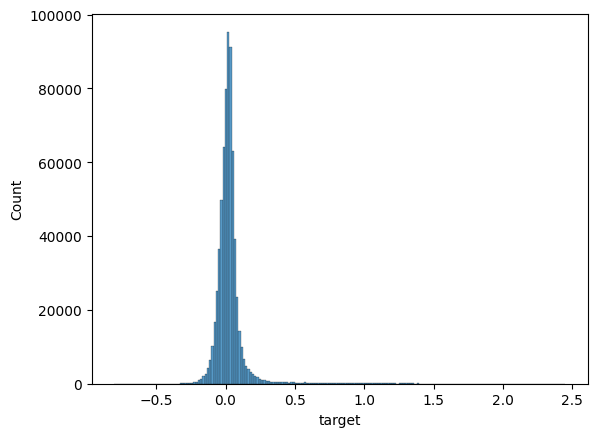

In [7]:
sns.histplot(df, x='target', bins = 200)

In [8]:
x1 = df['target'].min()
y1 = df['target'].max()

print(df['target'].max())
print(df['target'].min())
print(df['target'].unique())

2.4505363811874465
-0.8012949045786242
[-0.0172619  -0.05038419  0.00459682 ... -0.04855664 -0.09740643
 -0.08728516]


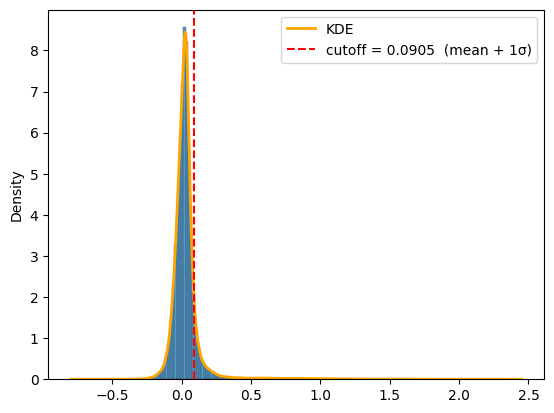

In [9]:
from scipy.stats import gaussian_kde

    # """
    # Finds the active/inactive cutoff by modelling the inactive population.

    # The left half of the distribution is purely inactive (no contamination from actives).
    # Mirror it to reconstruct a symmetric inactive Gaussian, then cut at mean + k*std.
    # k=2 captures ~97.7% of inactives; increase k to be more conservative.
    # Works for both a sharp inactive peak (Alpha Amylase) and a broad Gaussian inactive cluster (Try_B).
    # """
def TryB_ina_cut(data, k=1, bandwidth='scott'):
    data = np.array(data)
    kde = gaussian_kde(data, bw_method=bandwidth)
    x = np.linspace(data.min(), data.max(), 2000)
    y = kde(x)

    # Peak of the inactive cluster
    peak_x = x[np.argmax(y)]

    # Left side only (pure inactives), mirrored to reconstruct the full symmetric Gaussian
    left = data[data <= peak_x]
    mirrored = np.concatenate([left, 2 * peak_x - left])

    mean = mirrored.mean()  # ≈ peak_x
    std = mirrored.std()
    cutoff = mean + k * std

    # Plot to verify
    fig, ax = plt.subplots()
    sns.histplot(data, bins=200, ax=ax, stat='density')
    ax.plot(x, y, color='orange', linewidth=2, label='KDE')
    ax.axvline(cutoff, color='red', linestyle='--', label=f'cutoff = {cutoff:.4f}  (mean + {k}σ)')
    ax.legend()
    plt.show()

    return cutoff

dead_peak = TryB_ina_cut(df['target'])

In [10]:
# Try_B_assay, gaussian scaling
#in vivo competitive assay, linear scaling
def TryB_ina_cut(linear_scor_array, dead_peak_val=dead_peak):
    data = np.array(linear_scor_array)
    ceiling = data.max()
    normalized = (data - dead_peak_val) / (ceiling - dead_peak_val)
    return np.clip(normalized, 0, 1)


df['uni_scale'] = TryB_ina_cut(df['target'])

In [11]:
# # Imin Reductase Sigmoid scaling
# # Centered around 0 = WT activity, 
# def unify_ired(log_scores_array, k=1.0):
#     log_scores = np.array(log_scores_array)    
#     # Apply the sigmoidal transformation
#     unified_scores = 1 / (1 + np.exp(-k * log_scores))
    
#     return unified_scores

# #IRED add uniscale
# df['uni_scale'] = unify_ired(df['target'])
# df.head(1)
# print(df['target'].max())
# print(df['target'].min())
# print(df['uni_scale'].max())
# print(df['uni_scale'].min())

In [12]:
# #Alpha amylase
# def find_inac_cutoff(data, bandwidth='scott'):
#     """
#     Finds active/inactive cutoff via the KDE inflection point.
#     For a distribution with one sharp inactive peak + active tail:
#     looks at the right descending slope of the main peak and finds
#     where the curve transitions from steep decline into the flat tail
#     (= the inflection point = minimum of the first derivative).
#     """
#     from scipy.stats import gaussian_kde

#     data = np.array(data)
#     kde = gaussian_kde(data, bw_method=bandwidth)
#     x = np.linspace(data.min(), data.max(), 2000)
#     y = kde(x)

#     # Right side of the main (inactive) peak only
#     main_peak_idx = np.argmax(y)
#     x_right = x[main_peak_idx:]
#     y_right = y[main_peak_idx:]

#     # Inflection point = minimum of the first derivative on the descending slope
#     dy = np.gradient(y_right, x_right)
#     cutoff = x_right[np.argmin(dy)]

#     # Plot to verify
#     fig, ax = plt.subplots()
#     sns.histplot(data, bins=50, ax=ax, stat='density', )
#     ax.plot(x, y, color='orange', linewidth=2, label='KDE')
#     ax.axvline(cutoff, color='red', linestyle='--', label=f'cutoff = {cutoff:.4f}')
#     ax.legend()
#     plt.show()

#     return cutoff


# dead_peak = find_inac_cutoff(df['target'])
# print(dead_peak)

In [13]:
# # Alpha Amylase
# #stain removel assay, linear scaling
# def unify_alpha_amylase(linear_scor_array, dead_peak_val=dead_peak):
#     data = np.array(linear_scor_array)
#     ceiling = data.max()
#     normalized = (data - dead_peak_val) / (ceiling - dead_peak_val)
#     return np.clip(normalized, 0, 1)


# df['uni_scale'] = unify_alpha_amylase(df['target'])


In [14]:
df.head()

,id,sequence,set,validation,target,uni_scale
3706,2TB_000001,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,-0.017262,0.0
3707,2TB_000002,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,-0.050384,0.0
3708,2TB_000003,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,0.004597,0.0
3709,2TB_000004,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,0.025089,0.0
3710,2TB_000005,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,-0.074132,0.0


In [15]:
# sns.histplot(df, x='uni_scale', bins = 40)
counts_uni = (df['uni_scale'] == 0).value_counts()
print(counts_uni)

uni_scale
True     612102
False     72792
Name: count, dtype: int64


In [16]:
# sns.countplot(x=(df['target'] >= dead_peak))
counts = (df['target'] >= dead_peak).value_counts()
print(counts)

target
False    612102
True      72792
Name: count, dtype: int64


In [17]:
df1 = df.drop('target', axis =1)
df1 = df1[['id','sequence','set','validation','uni_scale']]
df1.head()

,id,sequence,set,validation,uni_scale
3706,2TB_000001,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,0.0
3707,2TB_000002,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,0.0
3708,2TB_000003,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,0.0
3709,2TB_000004,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,0.0
3710,2TB_000005,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,test,False,0.0


In [18]:
df2 =  df1[df1['set'] == 'train']
df2['uni_scale'].max()
# df1['uni_scale'].max()df1['uni_scale'].min()

np.float64(0.7434162447121501)

In [ ]:
# out_dir = (df['id'].str[1:3] == 'TB')

In [22]:
df1.to_csv(out_dir + "/TB.csv", index=False)